In [27]:
include("../src/channels.jl")
using PyPlot

# Channel Capacity Simulation

## Setup
- Initial state: Maximally entangled state between system (qubits 1:n) and ancilla (qubits n+1:2n)
- Circuit acts only on the system qubits
- System has periodic boundary conditions

## Single layer update:
1. Random 2-qubit Clifford gates on all even bonds: (1,2), (3,4), ...
2. Random 2-qubit Clifford gates on all odd bonds: (2,3), (4,5), ..., (n,1)
3. Replace-up channel on each system qubit with probability p

In [28]:
"""
    random_sign_free_clifford(n)

Generate a random sign-free Clifford gate on n qubits.
Sign-free means X maps to products of X only, and Z maps to products of Z only.
"""
function random_sign_free_clifford(n)
    xz = binary_random_sign_free_symplectic_matrix(n)
    s = fill(0, 2n)  # All phases are 0 for sign-free Clifford
    return Clifford(xz, s)
end

"""
    capacity_layer!(state, n_sys, p)

Apply a single layer of the circuit on the system qubits (1:n_sys).
The state has 2*n_sys qubits total (system + ancilla).

Steps:
1. Random sign-free 3-qubit Clifford gates on bonds: (1,2,3), (4,5,6), ...
2. Random sign-free 3-qubit Clifford gates on bonds: (2,3,4), (5,6,7), ...
3. Random sign-free 3-qubit Clifford gates on bonds: (3,4,5), (6,7,8), ...
4. Replace-up channel on each system qubit with probability p
"""
function capacity_layer!(state, n_sys, p)
    # Layer 1: (1,2,3), (4,5,6), (7,8,9), ...
    for i in 1:3:n_sys-2
        cl = random_sign_free_clifford(3)
        clifford_action!(cl, state, [i, i+1, i+2])
    end
    
    # Layer 2: (2,3,4), (5,6,7), (8,9,10), ... with PBC
    for i in 2:3:n_sys-2
        cl = random_sign_free_clifford(3)
        clifford_action!(cl, state, [i, i+1, i+2])
    end
    # Handle periodic boundary for layer 2
    if mod(n_sys - 1, 3) == 0
        cl = random_sign_free_clifford(3)
        clifford_action!(cl, state, [n_sys-1, n_sys, 1])
    end
    
    # Layer 3: (3,4,5), (6,7,8), (9,10,11), ... with PBC
    for i in 3:3:n_sys-2
        cl = random_sign_free_clifford(3)
        clifford_action!(cl, state, [i, i+1, i+2])
    end
    # Handle periodic boundary for layer 3
    if mod(n_sys, 3) == 0
        cl = random_sign_free_clifford(3)
        clifford_action!(cl, state, [n_sys, 1, 2])
    end
    
    # Replace-up channel on each system qubit with probability p
    for i in 1:n_sys
        if rand() < p
            replace_up!(state, i)
            # depolarize!(state, i) 
        end
    end
    
    return nothing
end

"""
    run_capacity_simulation(n_sys, p, n_steps; n_average=100)

Run the channel capacity simulation.

Arguments:
- n_sys: number of system qubits (also number of ancilla qubits)
- p: probability of replace-up channel on each qubit
- n_steps: number of time steps
- n_average: number of disorder averages

Returns:
- mi_history: mutual information between system and ancilla at each time step
- neg_history: negativity between system and ancilla at each time step
"""
function run_capacity_simulation(n_sys, p, n_steps; n_average=100)
    mi_history = zeros(n_steps + 1)
    neg_history = zeros(n_steps + 1)
    
    sys_region = collect(1:n_sys)
    anc_region = collect(n_sys+1:2*n_sys)
    
    for _ in 1:n_average
        # Initialize maximally entangled state: EPR pairs between system and ancilla
        # epr_pairs(n) creates n EPR pairs, so 2n qubits total
        state = epr_pairs(n_sys)
        
        # Measure initial mutual information and negativity
        mi_history[1] += mutual_info(state, sys_region, anc_region)
        neg_history[1] += mutual_neg(state, sys_region, anc_region)
        
        for t in 1:n_steps
            capacity_layer!(state, n_sys, p)
            mi_history[t+1] += mutual_info(state, sys_region, anc_region)
            neg_history[t+1] += mutual_neg(state, sys_region, anc_region)
        end
    end
    
    mi_history ./= n_average
    neg_history ./= n_average
    return mi_history, neg_history
end

run_capacity_simulation

## Example Usage

In [29]:
# Example: Run simulation for different values of p
n_sys = 32
p_list = 0.1:0.1:0.9
n_steps = 40
n_average = 100

mi_results = Dict{Float64, Vector{Float64}}()
neg_results = Dict{Float64, Vector{Float64}}()
for p in p_list
    println("Running p = $p ...")
    mi, neg = run_capacity_simulation(n_sys, p, n_steps; n_average=n_average)
    mi_results[p] = mi
    neg_results[p] = neg
end

Running p = 0.1 ...
Running p = 0.2 ...
Running p = 0.3 ...
Running p = 0.4 ...
Running p = 0.5 ...
Running p = 0.6 ...
Running p = 0.7 ...
Running p = 0.8 ...
Running p = 0.9 ...


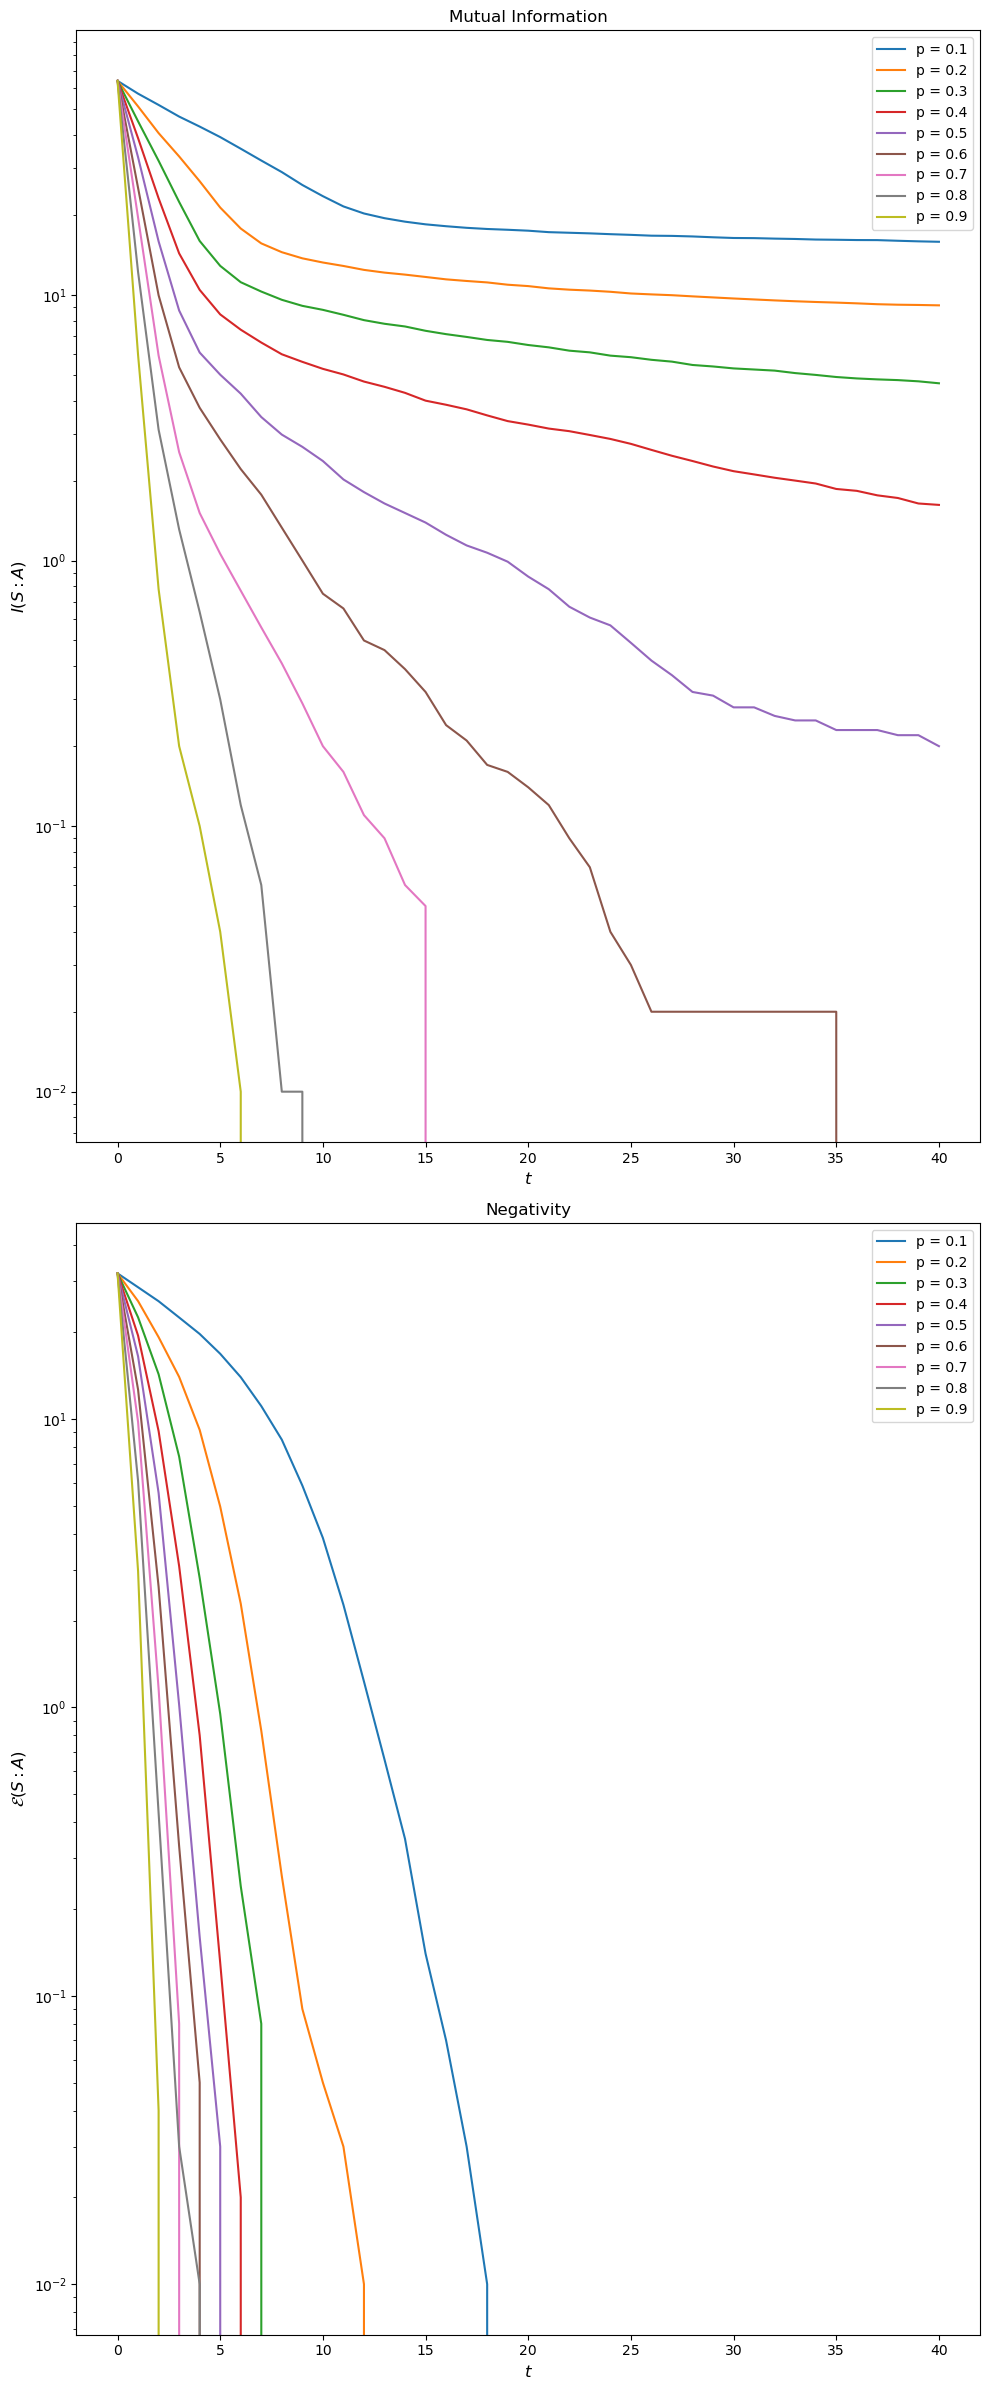

In [30]:
# Plot results
fig, axes = subplots(2, 1, figsize=(10, 24))

# Plot mutual information
for p in p_list
    mi = mi_results[p]
    axes[1].plot(0:n_steps, mi, "-", label="p = $p", lw=1.5)
end
axes[1].set_xlabel(L"t", fontsize=12)
axes[1].set_ylabel(L"I(S:A)", fontsize=12)
axes[1].set_title("Mutual Information")
axes[1].set_yscale("log")
axes[1].legend()

# Plot negativity
for p in p_list
    neg = neg_results[p]
    axes[2].plot(0:n_steps, neg, "-", label="p = $p", lw=1.5)
end
axes[2].set_xlabel(L"t", fontsize=12)
axes[2].set_ylabel(L"\mathcal{E}(S:A)", fontsize=12)
axes[2].set_title("Negativity")
axes[2].set_yscale("log")
axes[2].legend()

tight_layout()